## Algoritmos Ensamblados

La técnica de ensamble de algoritmos consiste en combinar varios modelos al mismo tiempo para solucionar un mismo problema con el objetivo de obtener mejores predicciones. Son una herramienta muy útil para mejorar el rendimiento de los modelos de aprendizaje automático.
Existen diferentes tipos de ensamblado, siendo los más utilizados:

**Bagging**: se construyen múltiples modelos de un mismo algoritmo, con diferentes subconjuntos del dataset de entrenamiento, la predicción final se realiza mediante estadísticas simples para combinar las predicciones  (por ejemplo la media de las predicciones de todos los modelos).

**Boosting:** se construyen múltiples modelos de un mismo algoritmo ensamblados secuencialmente,  cada modelo aprende a corregir los errores de predicción del modelo anterior en la secuencia.

**Voting:** se construyen múltiples modelos de distintos algoritmos, y se usan estadísticas simples para combinar las predicciones  (por ejemplo la media de las predicciones de todos los modelos).



In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import tree, metrics
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier #Arboles de decisión para Clasificaciòn
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score



Para esta práctica utilizaremos nuevamente el Dataset que usamos para árboless de decisión, correspondientes a 23 especies de hongos con branquias en el Agaricus de la  Familia Lepiota. Cada especie se identifica como definitivamente comestible, definitivamente venenoso o de comestibilidad desconocida y no recomendado. Esta última clase se combinó con los venenosos.

In [ ]:
dfAgaricusLepiota=pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vSV_0nnBuRbEN8dvWe84US2_f7JQrC_ZAa3lQAwyFERKsDqLwO864wkGXsHHE8j8A/pub?gid=808341260&single=true&output=csv')

##PREPROCESAMIENTO

In [ ]:
dfAgaricusLepiota

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [ ]:
dfAgaricusLepiota.shape

(8124, 23)

Tiene 8124 instancias, 23 atributos. El objetivo será clasificar en venenoso o comestible.
Informaciòn de los atributos:
1. Attribute Information: (class: edible=e, poisonous=p)
     1. cap-shape:                
                                  bell=b,conical=c,convex=x,flat=f,knobbed=k,sunken=s
     2. cap-surface:              
                                  fibrous=f,grooves=g,scaly=y,smooth=s
     3. cap-color:                
                                  brown=n,buff=b,cinnamon=c,gray=g,green=r,pink=p,purple=u,red=e,white=w,yellow=y
     4. bruises:
                                  bruises=t,no=f
     5. odor:
                                  almond=a,anise=l,creosote=c,fishy=y,foul=f,musty=m,none=n,pungent=p,spicy=s
     6. gill-attachment:
                                  attached=a,descending=d,free=f,notched=n
     7. gill-spacing:
                                  close=c,crowded=w,distant=d
     8. gill-size:
                                  broad=b,narrow=n
     9. gill-color:
                                 black=k,brown=n,buff=b,chocolate=h,gray=g,green=r,orange=o,pink=p,purple=u,red=e,
                                  white=w,yellow=y
    10. stalk-shape:
                                  enlarging=e,tapering=t
    11. stalk-root:
                                  bulbous=b,club=c,cup=u,equal=e,rhizomorphs=z,rooted=r,missing=?
    12. stalk-surface-above-ring:
                                  fibrous=f,scaly=y,silky=k,smooth=s
    13. stalk-surface-below-ring:
                                  fibrous=f,scaly=y,silky=k,smooth=s
    14. stalk-color-above-ring:   
                                  brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y
    15. stalk-color-below-ring:
                                  brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y
    16. veil-type:
                                  partial=p,universal=u
    17. veil-color:
                                   brown=n,orange=o,white=w,yellow=y
    18. ring-number:
                                   none=n,one=o,two=t
    19. ring-type:                
                                  cobwebby=c,evanescent=e,flaring=f,large=l,none=n,pendant=p,sheathing=s,zone=z
    20. spore-print-color:        
                                  black=k,brown=n,buff=b,chocolate=h,green=r,orange=o,purple=u,white=w,yellow=y
    21. population:               
                                  abundant=a,clustered=c,numerous=n,scattered=s,several=v,solitary=y
    22. habitat:                 
                                 grasses=g,leaves=l,meadows=m,paths=p,urban=u,waste=w,woods=d

2. **Missing** Attribute Values: 2480 of them (denoted by **"?"**), all for
   attribute #11 **stalk-root**

In [ ]:
dfAgaricusLepiota['stalk-root'].value_counts()

b    3776
?    2480
e    1120
c     556
r     192
Name: stalk-root, dtype: int64

Borraremos la columna stalk-root ya que tienen demasiadas instancias con valor indefinido (missing = ?)

In [ ]:
dfAgaricusLepiota.drop('stalk-root', axis=1, inplace=True) #axis=1 indica que es una columna


Evaluemos la cantidad de instancias según la clase objetivo

In [ ]:
dfAgaricusLepiota['class'].value_counts()

e    4208
p    3916
Name: class, dtype: int64

Las clases se encuentran balanceadas

In [ ]:
dfAgaricusLepiota.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-surface-above-ring  8124 non-null   object
 12  stalk-surface-below-ring  8124 non-null   object
 13  stalk-color-above-ring    8124 non-null   object
 14  stalk-color-below-ring  

In [ ]:
dfAgaricusLepiota.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


Borraremos la columnas que tienen una clase que incluye practicamente todas las instancias, porque consideramos que no brindarán información significativa para la clasificación.
Observar por ejemplo ring-number, que tiene 3 valores posibles, el valor o tienen 7488 instancias, siendo la clase comestible (class = e) 4208 instancias, y venenoso (class=p) 3916 instancias, dicho atributo no brindará mucha información.

In [ ]:
dfAgaricusLepiota.drop('gill-attachment', axis=1, inplace=True)
dfAgaricusLepiota.drop('gill-spacing', axis=1, inplace=True)
dfAgaricusLepiota.drop('veil-type', axis=1, inplace=True)
dfAgaricusLepiota.drop('veil-color', axis=1, inplace=True)
dfAgaricusLepiota.drop('ring-number', axis=1, inplace=True)

# Análisis bi-variado contra la clase objetivo
A continuación se muestra gráficamente y medienta una tabla de contingencia las frecuencias de cada una de las todas las variables y su relación contra la clase objetivo

**Histogramas de frecuencia**
Para facilitar el formateo de los gráficos y poderlos construir iterando sobre los atributos se creraá un vector con los nombres de los atrubitos (columnas del dataframe)

In [ ]:
NombresAtributos=dfAgaricusLepiota.columns


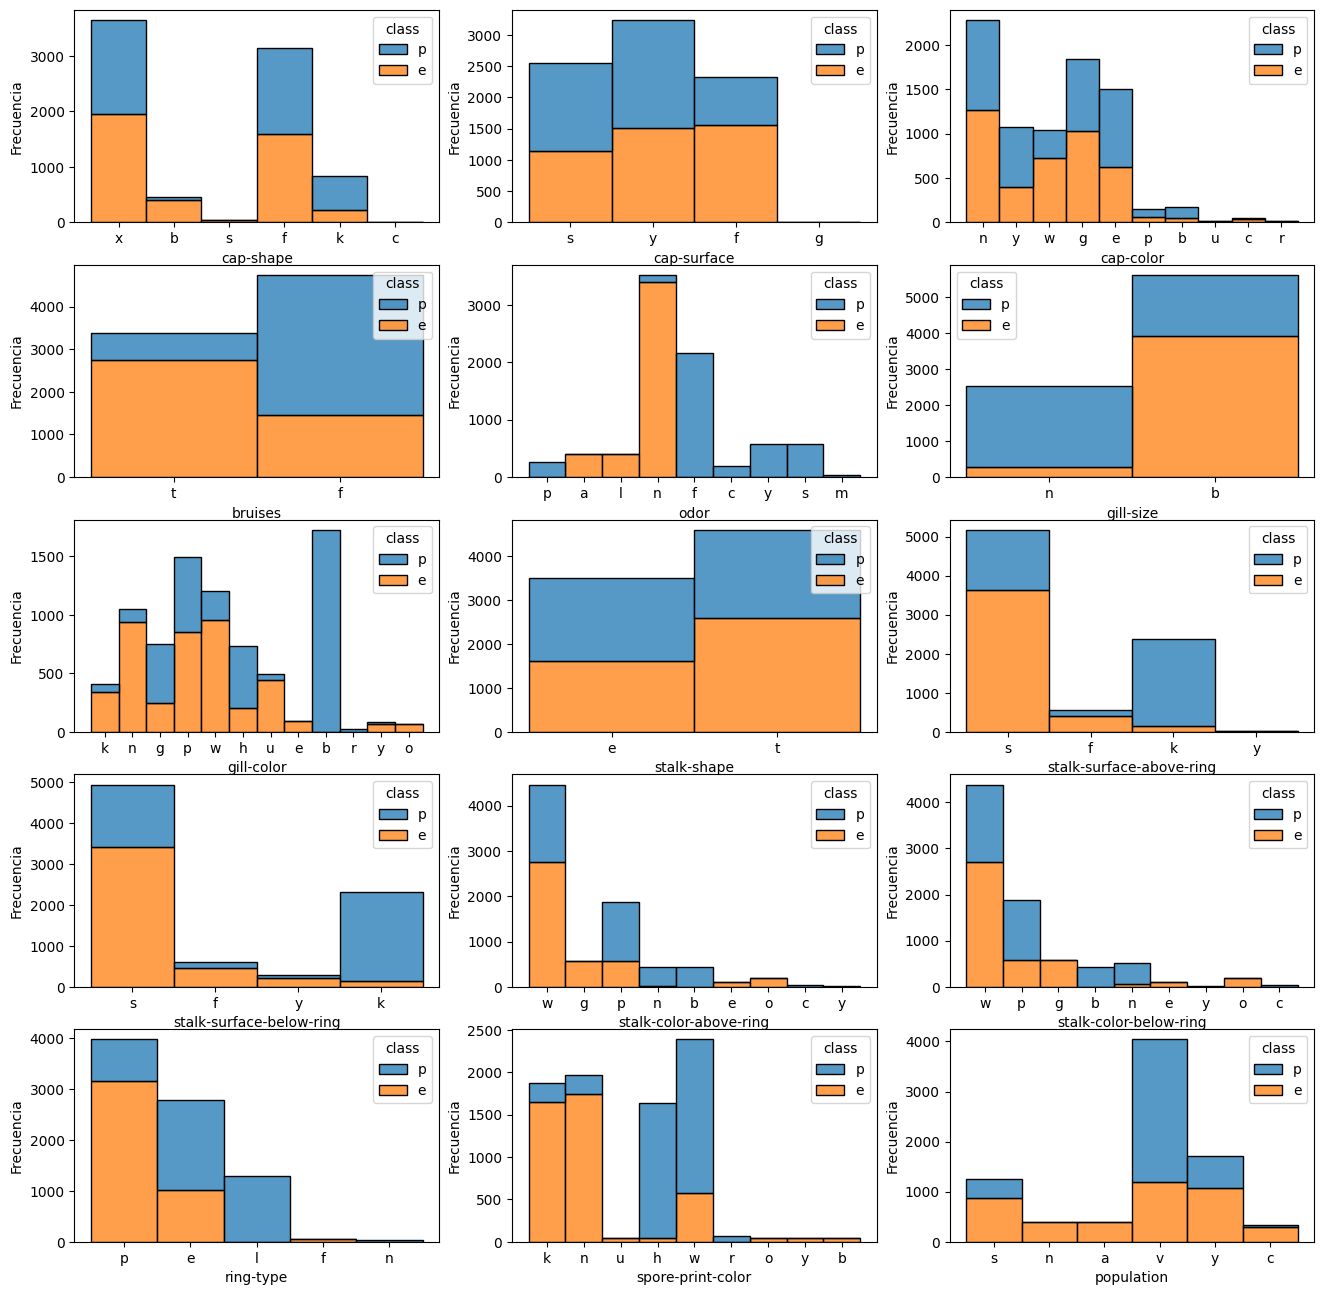

In [ ]:
fig, ax = plt.subplots(nrows=5, ncols=3, figsize=(16, 16), sharex=False)

for i in (0,1,2,3,4):
  for j in (1,2,3):
    c=i*3+j
    sns.histplot(data=dfAgaricusLepiota[NombresAtributos[c]], x=dfAgaricusLepiota[NombresAtributos[c]], label=NombresAtributos[c],  ax=ax[i,j-1], hue=dfAgaricusLepiota['class'], multiple='stack')
    ax[i,j-1].set_xlabel(NombresAtributos[c])
    ax[i,j-1].set_ylabel('Frecuencia')

**Elección de atributos, según como dividen la variable objetivo**

Viendo los gráficos podríamos elegir como buenos separadores de las clases objetivos: bruises, gill-size, odor, spore-print-color, ring-type.
Para el caso de bagging no pre-seleccionaremos los atributos ya que dejaremos que los modelos débiles se construyan con todos los atributos. Por ello la cantidad de modelos será alta para este dataset ya que son muchas variables.

In [ ]:
X = dfAgaricusLepiota[ dfAgaricusLepiota.columns[1:17]].values
XNombresAtributos= dfAgaricusLepiota.columns[1:17]
yNombresClases=['e','p']
y = dfAgaricusLepiota['class'].values
print(X)
print(y)
print(XNombresAtributos)

[['x' 's' 'n' ... 'k' 's' 'u']
 ['x' 's' 'y' ... 'n' 'n' 'g']
 ['b' 's' 'w' ... 'n' 'n' 'm']
 ...
 ['f' 's' 'n' ... 'b' 'c' 'l']
 ['k' 'y' 'n' ... 'w' 'v' 'l']
 ['x' 's' 'n' ... 'o' 'c' 'l']]
['p' 'e' 'e' ... 'e' 'p' 'e']
Index(['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-size',
       'gill-color', 'stalk-shape', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'ring-type', 'spore-print-color',
       'population', 'habitat'],
      dtype='object')


**Preparación de los datos para un modelo de arbol de decisión**

Los árboles en Python trabajan con variables categóricas pero numéricas por lo tanto será necesario codificarlas.
Para ello utilizaremos LabelEncoder.
Tanto para los atributos de entrada como también para la variable objetivo.

In [ ]:
le = LabelEncoder()
for i in range(16):
  X[:,i] = le.fit_transform(X[:,i])
print(X)
y = le.fit_transform(y)
print(y)

[[5 2 4 ... 2 3 5]
 [5 2 9 ... 3 2 1]
 [0 2 8 ... 3 2 3]
 ...
 [2 2 4 ... 0 1 2]
 [3 3 4 ... 7 4 2]
 [5 2 4 ... 4 1 2]]
[1 0 0 ... 0 1 0]


# Ensamblado
Utilizaremos BaggingClassifier sus parámetros son:

**estimator**: es el algoritmos que se utilizará en los modelos débiles que serán entrenados por el subconjunto aletario de los datos. Si no se setea este parámetro por default será un DecisionTreeClassifier.

**n_estimators**: Cantidad de modelos a ensamblar.

**max_samples**: Cantidad de instancias máxima que tendrá cada subconjunto de entranamiento para cada modelo débil.

**max_features**: Cantidad de características que se extraerán del dataset para cada modelo.

**bootstrap**: Indica si las instancias de los subconjuntos se extaerán con reposición o sin reposición. Falso indica sin reposición por lo tanto una instancia aparecerá en un único subconjunto).

**bootstrap_feature**s: Indica si las características de entrada al modelo se seleccionan con reposición o sin reposición. Falso indica sin reposición por lo tanto una característica se seleccionará para un único modelo débil.


El particionamiento del dataset original en ensamblado se realiza del mismo modo que en un modelo simple.
Los subconjuntos de entrenamiento se extraerán de la partición de entrenamiento automáticamente según los hiperparámetros que le hayamos configurado.




In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [ ]:
arbol = DecisionTreeClassifier()
bagging_arbol = BaggingClassifier(estimator=arbol, n_estimators=100, max_samples=900,bootstrap=True,bootstrap_features=True, random_state=42)
bagging_arbol.fit(X_train, y_train)


BaggingClassifier(bootstrap_features=True, estimator=DecisionTreeClassifier(),
                  max_samples=900, n_estimators=100, random_state=42)

# Evaluación
Una vez entrenado el modelo, debemos realizar el test y evaluar los resultados. Por tratarse de una clasificación utilizaremos la matriz de confusión. A continuación recordamos las fórmulas con 2 clases (positivo y negativo)

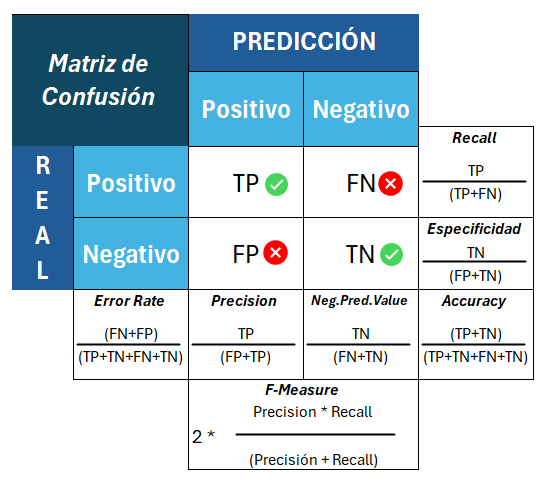

In [ ]:
y_pred=bagging_arbol.predict(X_test)

In [ ]:
mc_bagging_arbol=confusion_matrix(y_test, y_pred) #Matriz de confusion con las etiquetas reales de Test y los valores predichos
#mc_visual = metrics.ConfusionMatrixDisplay(confusion_matrix = bagging_arbol, display_labels = ['edible', 'poisonous']) # edible=e=0, poisonous=p=1
#mc_visual.plot()
# Reporte de clasificación
print(mc_bagging_arbol)
print(classification_report(y_test, y_pred))

[[1272    0]
 [   0 1166]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1272
           1       1.00      1.00      1.00      1166

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



# Conclusiones
Se contruyeron 100 árboles y fueron entrenados con 900 instancias cada uno.
El accuracy de 1, y el resto de las métricas también, por lo tanto podría considerarse un sobreentrenamiento, producto de la cantidad de árboles, ya que dado el tamaño del dataset, y la reposición en la creación de los diferentes subconjuntos de entrenamiento para cada árbol, probablemente un mismo esté repetido en el bagging más de una vez.  
Siendo que la predicción final se corresponde con la clase que más cantidad de modelos débiles predijeron.


#Ejercicio
Realizar una notebook con el mismo dataset que implemente boosting.